In [1]:
#Script developed by Justine Hansen 
#Original script: https://github.com/netneurolab/hansen_receptors/blob/main/code/https://github.com/netneurolab/hansen_receptors/blob/main/code/disease.py
#Reference: Hansen JY et al. 'Mapping neurotransmitter systems to the structural and functional organization of the human neocortex' Nat Neurosci 2022


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netneurotools import datasets, stats, utils
from scipy.stats import zscore, pearsonr, ttest_ind
import seaborn as sns
from matplotlib.colors import ListedColormap
from scipy.spatial.distance import squareform, pdist
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multitest import multipletests

In [2]:
def get_reg_r_sq(X, y):
    lin_reg = LinearRegression()
    lin_reg.fit(X, y)
    yhat = lin_reg.predict(X)
    SS_Residual = sum((y - yhat) ** 2)
    SS_Total = sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (float(SS_Residual)) / SS_Total
    adjusted_r_squared = 1 - (1 - r_squared) * \
        (len(y) - 1) / (len(y) - X.shape[1] - 1)
    return adjusted_r_squared


def cv_slr_distance_dependent(X, y, coords, train_pct=.75, metric='rsq'):
    '''
    cross validates linear regression model using distance-dependent method.
    X = n x p matrix of input variables
    y = n x 1 matrix of output variable
    coords = n x 3 coordinates of each observation
    train_pct (between 0 and 1), percent of observations in training set
    metric = {'rsq', 'corr'}
    '''

    P = squareform(pdist(coords, metric="euclidean"))
    train_metric = []
    test_metric = []
    
    for i in range(len(y)):
        distances = P[i, :]  # for every node
        idx = np.argsort(distances)

        train_idx = idx[:int(np.floor(train_pct * len(coords)))]
        test_idx = idx[int(np.floor(train_pct * len(coords))):]

        mdl = LinearRegression()
        mdl.fit(X[train_idx, :], y[train_idx])
        if metric == 'rsq':
            # get r^2 of train set
            train_metric.append(get_reg_r_sq(X[train_idx, :], y[train_idx]))

        elif metric == 'corr':
            rho, _ = pearsonr(mdl.predict(X[train_idx, :]), y[train_idx])
            train_metric.append(rho)

        yhat = mdl.predict(X[test_idx, :])
        if metric == 'rsq':
            # get r^2 of test set
            SS_Residual = sum((y[test_idx] - yhat) ** 2)
            SS_Total = sum((y[test_idx] - np.mean(y[test_idx])) ** 2)
            r_squared = 1 - (float(SS_Residual)) / SS_Total
            adjusted_r_squared = 1-(1-r_squared)*((len(y[test_idx]) - 1) /
                                                  (len(y[test_idx]) -
                                                   X.shape[1]-1))
            test_metric.append(adjusted_r_squared)

        elif metric == 'corr':
            rho, _ = pearsonr(yhat, y[test_idx])
            test_metric.append(rho)

    return train_metric, test_metric

def get_perm_p(emp, null):
    return (1 + sum(abs(null - np.mean(null))
                    > abs(emp - np.mean(null)))) / (len(null) + 1)


def get_reg_r_pval(X, y, spins, nspins):
    emp = get_reg_r_sq(X, y)
    null = np.zeros((nspins, ))
    for s in range(nspins):
        null[s] = get_reg_r_sq(X[spins[:, s], :], y)
    return (1 + sum(null > emp))/(nspins + 1)

In [3]:

"""
set-up
"""

scale = 'scale033'
path = '/Users/charlie/Desktop/my_projects/neurotransmitter/github/'

In [4]:
# set up parcellation
cammoun = datasets.fetch_cammoun2012()
info = pd.read_csv(cammoun['info'])
cortex = info.query('scale == "scale033" & structure == "cortex"')['id']
cortex = np.array(cortex) - 1  # python indexing
hemiid = np.array(info.query('scale == "scale033"')['hemisphere'])
hemiid = hemiid == 'R'
coords = utils.get_centroids(cammoun[scale], image_space=True)
coords = coords[cortex, :]
nnodes = len(cortex)
nspins = 10000
spins = stats.gen_spinsamples(coords, hemiid[cortex], n_rotate=nspins, seed=1234)

In [6]:
receptor_data = np.genfromtxt(path+'results/cammoun_zscored_receptor_data_scale068.csv', delimiter=',', filling_values=-0.055193734)
receptor_names = np.load(path+'data/receptor_names_pet.npy')

In [7]:
#NODE
ct = np.genfromtxt(path+'/data/modified_enigma_atrophy_node.csv', delimiter=',')
disorders = ['node_track', 'node_trackon', 'node_yas']

In [9]:
# colourmaps
cmap = np.genfromtxt(path+'data/colourmap.csv', delimiter=',')
cmap_div = ListedColormap(cmap)
cmap_seq = ListedColormap(cmap[128:, :])

0
1
2
['exc', 'inh']
Ttest_indResult(statistic=-1.9199391381251827, pvalue=0.06151522985377549)
['monoamine', 'not']
Ttest_indResult(statistic=0.12091242614219364, pvalue=0.9042010527702443)
['metabotropic', 'ionotropic']
Ttest_indResult(statistic=0.48071547190022074, pvalue=0.6331556470489235)
['gs', 'gi', 'gq']
Ttest_indResult(statistic=-1.6567548438627746, pvalue=0.1100680498777606)
Ttest_indResult(statistic=-0.21254643199689688, pvalue=0.8343649966374402)
Ttest_indResult(statistic=1.5606395531337773, pvalue=0.13117975097187243)


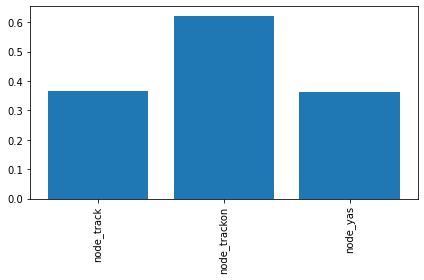

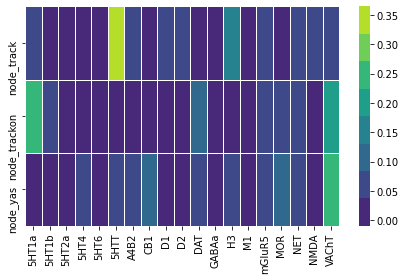

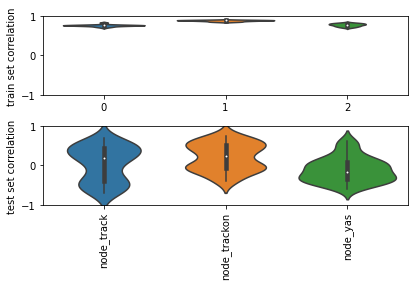

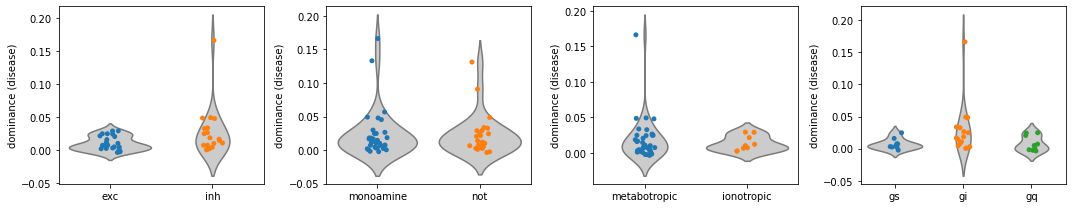

In [10]:
"""
Dominance analysis
"""

model_metrics = dict([])
train_metric = np.zeros([nnodes, len(disorders)])
test_metric = np.zeros(train_metric.shape)
model_pval = np.zeros((len(disorders), ))

for i in range(len(disorders)):
    print(i)
    m, _ = stats.get_dominance_stats(zscore(receptor_data),
                                     zscore(ct[:, i]))
    model_metrics[disorders[i]] = m
    # cross validate the model
    train_metric[:, i], test_metric[:, i] = \
        cv_slr_distance_dependent(zscore(receptor_data), zscore(ct[:, i]),
                                  coords, .75, metric='corr')
    # get p-value of model
    model_pval[i] = get_reg_r_pval(zscore(receptor_data),
                                   zscore(ct[:, i]), 
                                   spins, nspins)
    
    

model_pval = multipletests(model_pval, method='fdr_bh')[1]

dominance = np.zeros((len(disorders), len(receptor_names)))

for i in range(len(model_metrics)):
    tmp = model_metrics[disorders[i]]
    dominance[i, :] = tmp["total_dominance"]
np.save(path+'results/dominance_enigma_test_node.npy', dominance)
np.save(path+'results/enigma_cv_train_test_node.npy', train_metric)
np.save(path+'results/enigma_cv_test_node.npy', test_metric)


plt.ion()
plt.figure()
plt.bar(np.arange(len(disorders)), np.sum(dominance, axis=1),
        tick_label=disorders)
plt.xticks(rotation='vertical')
plt.tight_layout()
plt.savefig(path+'figures/bar_dominance_enigma_test_node.eps')

dominance[np.where(model_pval >= 0.05)[0], :] = 0
plt.ion()
plt.figure()
# Define the number of colors you want to use
num_colors = 8

# Create a list of colors from a colormap
cmap = sns.color_palette("viridis", num_colors)

# Create a custom discrete color map
cmap_discrete = sns.color_palette(cmap, num_colors).as_hex()

sns.heatmap(dominance / np.sum(dominance, axis=1)[:, None],
            xticklabels=receptor_names, yticklabels=disorders,
            cmap=cmap_discrete, linewidth=.5)
plt.tight_layout()
plt.savefig(path+'figures/heatmap_dominance_enigma_test_node.eps')

# plot cross validation
fig, (ax1, ax2) = plt.subplots(2, 1)
sns.violinplot(data=train_metric, ax=ax1)
sns.violinplot(data=test_metric, ax=ax2)
ax1.set(ylabel='train set correlation', ylim=(-1, 1))
ax2.set_xticklabels(disorders, rotation=90)
ax2.set(ylabel='test set correlation', ylim=(-1, 1))
plt.tight_layout()
plt.savefig(path+'figures/violin_enigma_cv_test_node.eps')


# compare dominance across receptor classes
exc = ['5HT2a', '5HT4', '5HT6', 'D1', 'mGluR5', 'A4B2', 'M1', 'NMDA']
inh = ['5HT1a', '5HT1b', 'CB1', 'D2', 'GABAa', 'H3', 'MOR']
mami = ['5HT1a', '5HT1b', '5HT2a', '5HT4', '5HT6', '5HTT', 'D1',
        'D2', 'DAT', 'H3', 'NET']
nmami = list(set(receptor_names) - set(mami))
metab = ['5HT1a', '5HT1b', '5HT2a', '5HT4', '5HT6', 'CB1', 'D1',
         'D2', 'H3', 'M1', 'mGluR5', 'MOR']
iono = ['A4B2', 'GABAa', 'NMDA']
gspath = ['5HT4', '5HT6', 'D1']
gipath = ['CB1', 'D2', 'H3', '5HT1a', '5HT1b', 'MOR']
gqpath = ['5HT2a', 'mGluR5', 'M1']

i_exc = np.array([list(receptor_names).index(i) for i in exc])
i_inh = np.array([list(receptor_names).index(i) for i in inh])
i_mami = np.array([list(receptor_names).index(i) for i in mami])
i_nmami = np.array([list(receptor_names).index(i) for i in nmami])
i_metab =  np.array([list(receptor_names).index(i) for i in metab])
i_iono = np.array([list(receptor_names).index(i) for i in iono])
i_gs = np.array([list(receptor_names).index(i) for i in gspath])
i_gi = np.array([list(receptor_names).index(i) for i in gipath])
i_gq = np.array([list(receptor_names).index(i) for i in gqpath])

classes = [[i_exc, i_inh], [i_mami, i_nmami],
           [i_metab, i_iono], [i_gs, i_gi, i_gq]]
class_names = [['exc', 'inh'], ['monoamine', 'not'],
               ['metabotropic', 'ionotropic'], ['gs', 'gi', 'gq']]
plt.ion()
fig, axs = plt.subplots(1, 4, figsize=(15, 3))
axs = axs.ravel()
for i in range(len(classes)):
    print(class_names[i])
    d = [dominance[:, classes[i][j]].flatten() for j in range(len(classes[i]))]
    print(ttest_ind(d[0], d[1]))
    if len(d) > 2:
        print(ttest_ind(d[0], d[2]))
        print(ttest_ind(d[1], d[2]))
    sns.violinplot(data=d, inner=None, color=".8", ax=axs[i])
    sns.stripplot(data=d, ax=axs[i])
    axs[i].set_xticklabels(class_names[i])
    axs[i].set_ylabel('dominance (disease)')
plt.tight_layout()
plt.savefig(path+'figures/stripplot_enigma_rclasses_node.eps')